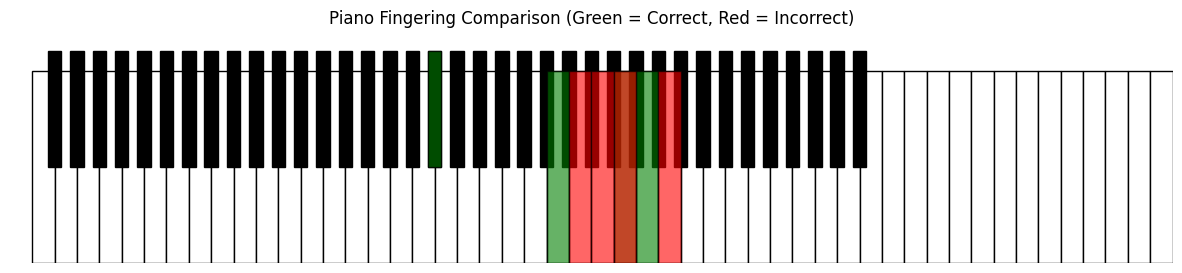

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1) Define piano keys (88 keys, standard range)
white_keys = [i for i in range(88) if i % 12 in [0, 2, 4, 5, 7, 9, 11]]  # C, D, E, F, G, A, B
black_keys = [i for i in range(88) if i % 12 in [1, 3, 6, 8, 10]]  # C#, D#, F#, G#, A#

# 2) Define key positions
white_positions = {k: i for i, k in enumerate(white_keys)}
black_positions = {k: i for i, k in enumerate(black_keys)}

# 3) Function to plot a piano
def plot_piano(correct_notes, incorrect_notes):
    fig, ax = plt.subplots(figsize=(15, 3))

    # Draw white keys
    for key in white_keys:
        rect = plt.Rectangle((white_positions[key], 0), 1, 1, edgecolor='black', facecolor='white')
        ax.add_patch(rect)

    # Draw black keys
    for key in black_keys:
        rect = plt.Rectangle((black_positions[key] + 0.7, 0.5), 0.6, 0.6, edgecolor='black', facecolor='black')
        ax.add_patch(rect)

    # Highlight correct notes (Green)
    for note in correct_notes:
        if note in white_keys:
            rect = plt.Rectangle((white_positions[note], 0), 1, 1, edgecolor='black', facecolor='green', alpha=0.6)
        else:
            rect = plt.Rectangle((black_positions[note] + 0.7, 0.5), 0.6, 0.6, edgecolor='black', facecolor='green', alpha=0.6)
        ax.add_patch(rect)

    # Highlight incorrect notes (Red)
    for note in incorrect_notes:
        if note in white_keys:
            rect = plt.Rectangle((white_positions[note], 0), 1, 1, edgecolor='black', facecolor='red', alpha=0.6)
        else:
            rect = plt.Rectangle((black_positions[note] + 0.7, 0.5), 0.6, 0.6, edgecolor='black', facecolor='red', alpha=0.6)
        ax.add_patch(rect)

    # Formatting
    ax.set_xlim(-1, len(white_keys))
    ax.set_ylim(0, 1.2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    plt.title("Piano Fingering Comparison (Green = Correct, Red = Incorrect)")
    plt.show()

# 4) Example Usage
correct_fingering = [40, 42, 45, 47]  # Notes in MIDI
incorrect_fingering = [41, 43, 45, 48]  # Slightly off notes

plot_piano(correct_fingering, incorrect_fingering)


In [2]:
import pygame
import time

# 1) Initialize Pygame
pygame.init()
WIDTH, HEIGHT = 800, 300
screen = pygame.display.set_mode((WIDTH, HEIGHT))
pygame.display.set_caption("Piano Fingering Playback")

# 2) Define white and black keys
white_keys = [pygame.Rect(x * 40, 0, 40, 200) for x in range(21)]  # 21 white keys (partial keyboard)
black_keys = [pygame.Rect(x * 40 + 30, 0, 30, 120) for x in range(15)]  # 15 black keys (approximation)

# 3) Function to render piano with highlights
def draw_piano(correct_notes, incorrect_notes):
    screen.fill((255, 255, 255))  # White background

    # Draw white keys
    for key in white_keys:
        pygame.draw.rect(screen, (255, 255, 255), key, 0)
        pygame.draw.rect(screen, (0, 0, 0), key, 2)

    # Draw black keys
    for key in black_keys:
        pygame.draw.rect(screen, (0, 0, 0), key, 0)

    # Highlight correct notes (Green)
    for note in correct_notes:
        if note % 21 < len(white_keys):  # Ensure it's within range
            pygame.draw.rect(screen, (0, 255, 0), white_keys[note % 21], 0)

    # Highlight incorrect notes (Red)
    for note in incorrect_notes:
        if note % 21 < len(white_keys):  # Ensure it's within range
            pygame.draw.rect(screen, (255, 0, 0), white_keys[note % 21], 0)

    pygame.display.flip()

# 4) Define fingering playback sequence
fingering_sequence = [
    ([40, 42], [41]),    # Frame 1: Correct = 40, 42 | Incorrect = 41
    ([44, 47], [46]),    # Frame 2: Correct = 44, 47 | Incorrect = 46
    ([50, 52], [51]),    # Frame 3: Correct = 50, 52 | Incorrect = 51
    ([55, 57], [56]),    # Frame 4: Correct = 55, 57 | Incorrect = 56
    ([60, 62], [61]),    # Frame 5: Correct = 60, 62 | Incorrect = 61
]

# 5) Run the playback animation
running = True
for correct_fingering, incorrect_fingering in fingering_sequence:
    draw_piano(correct_fingering, incorrect_fingering)
    time.sleep(2)  # Pause for 2 seconds between frames

pygame.quit()


NameError: name 'predict_piece_fingerings_multi' is not defined